# Mixed NF-Logit (NF-MXL): Simulation Experiment — Scenario A (Normal)

This notebook reproduces **Scenario A** of the simulation study (the random coefficient
vector follows a **bivariate independent Normal distribution**) exactly as reported in
**Table 1** and **Figure 2** of the manuscript. The full pipeline is self-contained:
every function is inlined below, no project modules are imported.

**Pipeline (step by step)**

| Step | Section | What happens |
|------|---------|--------------|
| 1 | §1 | Environment, libraries and experimental configuration (seeds, sample sizes, draws) |
| 2 | §2 | Data-Generating Process: D-efficient design search, $\rho^2$ scale calibration, Gumbel error simulation of choices, long-format assembly, respondent-level 70/30 split, true log-likelihood |
| 3 | §3 | Benchmark — Mixed Logit (`xlogit`): search over the candidate mixing distributions (3000 draws, panels), select by train log-likelihood |
| 4 | §4 | Proposed model — Mixed NF-Logit (NF-MXL): normalizing-flow mixing distribution + panel simulated likelihood (PyTorch), train-plateau early stopping |
| 5 | §5 | Results table (Table 1 layout): estimated means/stds, RMSE/MAE, KL/JS/Wasserstein, log-likelihoods, McFadden's $\rho^2$, runtimes |
| 6 | §6 | Distribution-recovery figure (Figure 2 layout): True vs. MXL vs. NF-MXL, per random coefficient |
| 7 | §7 | Reproducibility notes (seeds, dependencies, expected runtime) |

Expected runtime: **~6–10 min on one GPU** (Mixed Logit $\approx$ 5–6 min, NF-MXL
$\approx$ 1–2 min); the Mixed Logit search runs on CPU.

## 1. Environment and experimental configuration

**Libraries**

| Library | Role in this notebook |
|---------|-----------------------|
| `numpy` / `pandas` | DGP (design search, calibration, choice simulation), result tables |
| `scipy.stats` | Gumbel errors for the DGP, Normal densities, Wasserstein distance |
| `matplotlib` / `seaborn` | distribution-recovery figure (Times New Roman, as in the manuscript) |
| `torch` / `torch.nn` | NF-MXL model (RealNVP normalizing flow) and its Adam training loop |
| `xlogit` | benchmark Mixed Logit estimator (BFGS on the panel simulated log-likelihood, Halton draws) |

**Configuration** (identical to the manuscript's experiment config):
data seed 2027; model seed 2024; $N=1000$ individuals; $T_n=12$ choice tasks; $J=4$
alternatives; 2 random coefficients; true $\beta\sim\mathcal N([1,-0.5],\mathrm{diag}(0.15,0.10))$
with a calibrated scale factor targeting true $\rho^2\approx0.25$; Mixed Logit $R=3000$
draws; NF-MXL: 4 coupling layers, hidden 64, $z$-dim 8, 200 training draws, 500
evaluation draws, lr $3\times10^{-3}$, batch 64, L2 $10^{-3}$, gradient clip 1.0,
train-plateau early stopping (tol $10^{-5}$, patience 300).

In [1]:
import time
import warnings
from itertools import product, combinations
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gumbel_r, norm, wasserstein_distance, gaussian_kde
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

warnings.filterwarnings('ignore')

# ---------------- SCI figure style (as in the manuscript) ----------------
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'SimSun'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    'axes.linewidth': 0.8,
    'axes.grid': True,
    'grid.alpha': 0.2,
    'grid.linestyle': '--',
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
})
SCI_COLORS = {
    'Mixed_Logit': '#55A868',
    'Mixed_NF_Logit': '#C44E52',
    'True_Distribution': '#000000',
    'NF_Learned': '#1f77b4',
    'ML_Normal': '#d62728',
    'grid': '#DDDDDD',
}
sns.set_style('whitegrid', {
    'axes.facecolor': 'white',
    'grid.color': SCI_COLORS['grid'],
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
})

print('numpy      :', np.__version__)
print('pandas     :', pd.__version__)
print('torch      :', torch.__version__, '| CUDA available:', torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---------------- experimental configuration ----------------
CONFIG = {
    'random_seed': 2024,          # model seed (np + torch + cuda)
    'n_individuals': 1000,
    'n_choices_per_individual': 12,
    'n_alternatives': 4,
    'n_vars': 2,
    'test_size': 0.3,
    'dgp_seed': 2027,             # data-generating seed
    # D-efficient design
    'design_levels': [-1.0, 0.0, 1.0],
    'design_n_bayes_draws': 200,
    'design_n_iter': 30,
    # rho^2 calibration
    'rho2_target': 0.25,
    'rho2_tolerance': 0.02,
    'rho2_max_iter': 30,
    'rho2_n_calib': 1000,
    # Mixed Logit (xlogit)
    'mixed_logit_n_draws': 3000,
    'mixed_logit_distributions': ['n', 'ln', 'u', 't', 'tn'],
    # NF-MXL
    'nf_layers': 4,
    'nf_hidden': 64,
    'z_dim': 8,
    'n_draws': 200,               # training draws
    'n_draws_eval': 500,          # evaluation draws
    'lr': 0.003,
    'batch_size': 64,
    'n_epochs': 10000,
    'early_stopping_patience': 300,
    'train_plateau_tol': 1e-5,
    'reg_weight': 0.001,
    # divergence metrics
    'divergence_n_bins': 100,
    'divergence_n_samples': 100000,
    'epsilon': 1e-10,
}
# true multivariate normal of the random coefficients (pre-calibration)
TRUE_BETA_MEAN = [1.0, -0.5]
TRUE_BETA_COV = [[0.15, 0.0], [0.0, 0.10]]
print('\nconfiguration:')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

numpy      : 2.2.6
pandas     : 2.3.3
torch      : 2.11.0.dev20260210+cu130 | CUDA available: True

configuration:
  random_seed: 2024
  n_individuals: 1000
  n_choices_per_individual: 12
  n_alternatives: 4
  n_vars: 2
  test_size: 0.3
  dgp_seed: 2027
  design_levels: [-1.0, 0.0, 1.0]
  design_n_bayes_draws: 200
  design_n_iter: 30
  rho2_target: 0.25
  rho2_tolerance: 0.02
  rho2_max_iter: 30
  rho2_n_calib: 1000
  mixed_logit_n_draws: 3000
  mixed_logit_distributions: ['n', 'ln', 'u', 't', 'tn']
  nf_layers: 4
  nf_hidden: 64
  z_dim: 8
  n_draws: 200
  n_draws_eval: 500
  lr: 0.003
  batch_size: 64
  n_epochs: 10000
  early_stopping_patience: 300
  train_plateau_tol: 1e-05
  reg_weight: 0.001
  divergence_n_bins: 100
  divergence_n_samples: 100000
  epsilon: 1e-10


## 2. Data-Generating Process (DGP)

The DGP follows the manuscript exactly (four steps):

1. **Random coefficients.** Each individual $n$ draws a taste vector
   $\beta_n \sim \mathcal N(\mu, \Sigma)$ with $\mu=(1.0,-0.5)'$ and
   $\Sigma=\mathrm{diag}(0.15,0.10)$ (independent bivariate Normal).
2. **D-efficient design.** Attributes are *not* independent uniforms: candidate profiles
   from the level grid $\{-1,0,1\}^2$ are combined into all $\binom{9}{4}=126$ possible
   4-alternative choice sets, and a random-start **exchange algorithm** maximises the
   log-determinant of the Bayesian MNL information matrix (200 draws of $\beta$ as the
   prior). Every individual faces the same 12 choice sets.
3. **$\rho^2$ calibration.** A global scale factor on $\beta$ is found by bisection so
   that the true McFadden's $\rho^2 \approx 0.25$ (choice difficulty representative of
   transport applications). Gumbel errors for the calibration are drawn from the
   dedicated stream `seed + 999`.
4. **Choices and split.** Utilities $U_{ntj}=x_{ntj}'(s\,\beta_n)+\varepsilon_{ntj}$ with
   i.i.d. Gumbel errors; the chosen alternative is $\arg\max_j U_{ntj}$. The long table
   (choice_id, person_id, alt, choice, x0, x1) is split **at the respondent level**
   (70/30, seed 2027): the two halves never share an individual.

The true log-likelihood of the DGP (logit choice probabilities evaluated at the realised
choices) and the true $\rho^2$ are recorded — these are the "True" column of Table 1.

*Random-stream fidelity*: `np.random.seed(2027)` is set once, then the beta draw, the
design search, the calibration errors (`2027+999`) and the split consume the stream in
exactly the same order as the original generator, so every number is bit-reproducible.

In [2]:
# ============================================================
# DGP part 1: random coefficients + D-efficient design search
# (inlined from data_generator_final.py)
# ============================================================

def set_random_seed(seed):
    '''Set the numpy seed for reproducibility.'''
    np.random.seed(seed)
    print(f'  [seed] random seed set to: {seed}')


def generate_random_beta(n_individuals, true_mean, true_cov):
    '''Draw the raw (unscaled) random coefficient matrix from the multivariate normal.'''
    beta_data = np.random.multivariate_normal(mean=true_mean, cov=true_cov,
                                              size=n_individuals)
    beta_df = pd.DataFrame(beta_data, columns=[f'beta_{i}' for i in range(len(true_mean))])
    beta_df['person_id'] = np.arange(n_individuals)
    return beta_df


def scale_beta(beta_df, scale_factor, n_vars):
    '''Apply the global rho^2 calibration scale factor to all random coefficients.'''
    scaled = beta_df.copy()
    beta_cols = [f'beta_{i}' for i in range(n_vars)]
    scaled[beta_cols] = scaled[beta_cols] * scale_factor
    return scaled


def generate_candidate_profiles(levels, n_vars):
    '''All possible attribute profiles from the Cartesian product of levels.'''
    profiles = np.array(list(product(levels, repeat=n_vars)), dtype=float)
    return profiles


def generate_candidate_choice_sets(profiles, n_alternatives):
    '''All candidate choice sets (combinations of distinct profiles).'''
    indices = list(combinations(range(len(profiles)), n_alternatives))
    candidate_sets = np.array([profiles[list(idx)] for idx in indices])
    return candidate_sets


def choice_set_information(choice_set, beta):
    '''MNL information-matrix contribution of one choice set.
    beta: (n_vars,) mean vector or (n_bayes, n_vars) Bayesian prior draws.'''
    if beta.ndim == 1:
        V = choice_set @ beta                      # (n_alts,)
        P = np.exp(V - np.max(V))
        P = P / P.sum()
        X_bar = (P[:, None] * choice_set).sum(axis=0)
        I = np.zeros((choice_set.shape[1], choice_set.shape[1]))
        for j in range(choice_set.shape[0]):
            diff = choice_set[j] - X_bar
            I += P[j] * np.outer(diff, diff)
        return I
    # Bayesian: average over prior draws of beta
    I_total = np.zeros((choice_set.shape[1], choice_set.shape[1]))
    for b in beta:
        I_total += choice_set_information(choice_set, b)
    return I_total / len(beta)


def find_d_efficient_design(n_alternatives, n_vars, n_sets, levels, beta_prior,
                            n_iter=30, verbose=True):
    '''Random start + exchange algorithm for an approximate D-efficient design.
    beta_prior: (n_vars,) mean or (n_bayes, n_vars) Bayesian draws.'''
    profiles = generate_candidate_profiles(levels, n_vars)
    candidate_sets = generate_candidate_choice_sets(profiles, n_alternatives)
    if verbose:
        print(f'    candidate profiles: {len(profiles)}, candidate choice sets: {len(candidate_sets)}')

    # precompute the information matrix of every candidate choice set
    info_matrices = np.array([choice_set_information(cs, beta_prior) for cs in candidate_sets])

    # random initial design
    idx = np.random.choice(len(candidate_sets), n_sets, replace=True)
    total_info = info_matrices[idx].sum(axis=0)
    sign, best_score = np.linalg.slogdet(total_info)
    if sign <= 0 or np.isnan(best_score) or np.isinf(best_score):
        best_score = -np.inf

    # exchange algorithm
    for it in range(n_iter):
        improved = False
        for i in range(n_sets):
            current_sum = total_info - info_matrices[idx[i]]
            candidate_sums = current_sum[None, :, :] + info_matrices
            signs, logdets = np.linalg.slogdet(candidate_sums)
            logdets[(signs <= 0) | np.isnan(logdets) | np.isinf(logdets)] = -np.inf
            best_j = int(np.argmax(logdets))
            if logdets[best_j] > best_score + 1e-12:
                total_info = current_sum + info_matrices[best_j]
                idx[i] = best_j
                best_score = logdets[best_j]
                improved = True
        if verbose:
            print(f'    iter {it + 1}/{n_iter}, log det(I) = {best_score:.4f}')
        if not improved:
            break

    design = [candidate_sets[i] for i in idx]
    all_X = np.vstack(design)
    corr = np.corrcoef(all_X.T)
    return design, best_score, corr

In [3]:
# ============================================================
# DGP part 2: rho^2 calibration, choice simulation, long table, split
# (inlined from data_generator_final.py)
# ============================================================

def compute_true_log_likelihood(design, beta_matrix, epsilon, n_alternatives):
    '''True DGP log-likelihood: logit probabilities at the realised choices.
    design: list of T_n choice sets; beta_matrix: (N, n_vars);
    epsilon: (N, T_n, n_alts) pre-drawn Gumbel errors.'''
    n_individuals = beta_matrix.shape[0]
    n_sets = len(design)
    design_arr = np.stack(design)                        # (T_n, n_alts, n_vars)
    V = np.einsum('ijk,nk->nij', design_arr, beta_matrix)  # (N, T_n, n_alts)
    U = V + epsilon
    choices = np.argmax(U, axis=-1)                      # (N, T_n)
    V_stable = V - np.max(V, axis=-1, keepdims=True)
    expV = np.exp(V_stable)
    P = expV / expV.sum(axis=-1, keepdims=True)          # true logit probabilities
    chosen_prob = P[np.arange(n_individuals)[:, None], np.arange(n_sets)[None, :], choices]
    chosen_prob = np.clip(chosen_prob, 1e-15, 1.0)
    ll = float(np.log(chosen_prob).sum())
    return ll, choices


def compute_rho2(true_ll, n_individuals, n_sets, n_alternatives):
    '''McFadden rho^2 against the equal-shares null model.'''
    null_ll = n_individuals * n_sets * np.log(1.0 / n_alternatives)
    rho2 = 1.0 - true_ll / null_ll
    return rho2, null_ll


def calibrate_beta_scale(design, raw_beta_matrix, config, verbose=True):
    '''Bisection search on the global beta scale so the DGP attains rho^2 ~ target.
    Returns (scale_factor, scaled_beta_matrix, final_choices, true_ll, null_ll, rho2).'''
    target = config['rho2_target']
    tolerance = config['rho2_tolerance']
    max_iter = config['rho2_max_iter']
    n_calib = min(config['rho2_n_calib'], raw_beta_matrix.shape[0])
    n_alternatives = design[0].shape[0]
    n_sets = len(design)
    calib_beta = raw_beta_matrix[:n_calib]

    # dedicated error stream for the calibration (same seed as the final errors)
    np.random.seed(config['dgp_seed'] + 999)
    epsilon = gumbel_r.rvs(loc=0, scale=1, size=(n_calib, n_sets, n_alternatives))
    np.random.seed(config['dgp_seed'])                   # restore the main stream

    def objective(s):
        if s <= 0:
            return -1.0
        scaled = calib_beta * s
        true_ll, _ = compute_true_log_likelihood(design, scaled, epsilon, n_alternatives)
        rho2, _ = compute_rho2(true_ll, n_calib, n_sets, n_alternatives)
        return rho2

    s_low, s_high = 1e-4, 10.0
    rho_low, rho_high = objective(s_low), objective(s_high)
    if verbose:
        print(f'    rho2 at s=1.0: {objective(1.0):.4f}')
        print(f'    bracket: s_low={s_low:.4f} -> rho2={rho_low:.4f}, '
              f's_high={s_high:.4f} -> rho2={rho_high:.4f}')
    while rho_high < target and s_high < 1e6:
        s_high *= 2
        rho_high = objective(s_high)
    while rho_low > target and s_low > 1e-8:
        s_low /= 2
        rho_low = objective(s_low)

    s_mid = s_low
    for _ in range(max_iter):
        s_mid = (s_low + s_high) / 2.0
        rho_mid = objective(s_mid)
        if abs(rho_mid - target) < tolerance:
            break
        if rho_mid < target:
            s_low = s_mid
        else:
            s_high = s_mid

    candidates = [(s_low, objective(s_low)), (s_mid, objective(s_mid)),
                  (s_high, objective(s_high))]
    scale_factor, best_rho = min(candidates, key=lambda x: abs(x[1] - target))

    scaled_beta_matrix = raw_beta_matrix * scale_factor

    # regenerate the full-sample Gumbel errors with the same dedicated stream
    np.random.seed(config['dgp_seed'] + 999)
    full_epsilon = gumbel_r.rvs(loc=0, scale=1,
                                size=(raw_beta_matrix.shape[0], n_sets, n_alternatives))
    np.random.seed(config['dgp_seed'])                   # restore the main stream

    true_ll, final_choices = compute_true_log_likelihood(
        design, scaled_beta_matrix, full_epsilon, n_alternatives)
    rho2, null_ll = compute_rho2(true_ll, raw_beta_matrix.shape[0], n_sets, n_alternatives)
    if verbose:
        print(f'    calibrated scale factor: {scale_factor:.6f}, true rho2: {rho2:.4f} '
              f'(target {target})')
        print(f'    true LL: {true_ll:.4f}, null LL: {null_ll:.4f}')
    return scale_factor, scaled_beta_matrix, final_choices, true_ll, null_ll, rho2


def generate_choice_data(config, beta_df, design, choices):
    '''Assemble the long-format choice table
    (choice_id, person_id, alt, choice, x0, x1, ...).'''
    n_individuals = config['n_individuals']
    n_alts = config['n_alternatives']
    n_vars = config['n_vars']
    beta_matrix = beta_df[[f'beta_{i}' for i in range(n_vars)]].values
    all_data = []
    choice_id_global = 0
    for person_id in range(n_individuals):
        for t, choice_set in enumerate(design):
            choice_alt = choices[person_id, t]
            for alt_idx in range(n_alts):
                obs = {'choice_id': choice_id_global,
                       'person_id': person_id,
                       'alt': alt_idx,
                       'choice': 1 if alt_idx == choice_alt else 0}
                for var_idx in range(n_vars):
                    obs[f'x{var_idx}'] = choice_set[alt_idx, var_idx]
                all_data.append(obs)
            choice_id_global += 1
    choice_df = pd.DataFrame(all_data)
    feature_cols = [f'x{i}' for i in range(n_vars)]
    other_cols = ['choice_id', 'person_id', 'alt', 'choice']
    return choice_df[other_cols + feature_cols]


def split_data_by_individual(choice_df, test_size=0.3, random_state=42):
    '''Respondent-level split: observations of one individual never cross sets.'''
    unique_persons = choice_df['person_id'].unique()
    np.random.seed(random_state)
    n_test = int(len(unique_persons) * test_size)
    test_persons = np.random.choice(unique_persons, size=n_test, replace=False)
    train_persons = np.setdiff1d(unique_persons, test_persons)
    train_df = choice_df[choice_df['person_id'].isin(train_persons)].copy()
    test_df = choice_df[choice_df['person_id'].isin(test_persons)].copy()
    return train_df, test_df, train_persons, test_persons

In [4]:
# ---------------- run the DGP exactly as in the paper's generator ----------------
set_random_seed(CONFIG['dgp_seed'])

# step 1: raw random coefficients beta_n (unscaled)
raw_beta_df = generate_random_beta(CONFIG['n_individuals'], TRUE_BETA_MEAN, TRUE_BETA_COV)
n_vars = CONFIG['n_vars']

# step 2: D-efficient design (Bayesian prior: first 200 raw beta draws)
beta_prior = raw_beta_df[[f'beta_{i}' for i in range(n_vars)]].values[:CONFIG['design_n_bayes_draws']]
design, log_det_fisher, corr_matrix = find_d_efficient_design(
    n_alternatives=CONFIG['n_alternatives'],
    n_vars=n_vars,
    n_sets=CONFIG['n_choices_per_individual'],
    levels=CONFIG['design_levels'],
    beta_prior=beta_prior,
    n_iter=CONFIG['design_n_iter'],
    verbose=True,
)
print(f'  design attribute correlation matrix:\n{np.round(corr_matrix, 4)}')

# step 3: calibrate the beta scale for true rho^2 ~ 0.25
raw_beta_matrix = raw_beta_df[[f'beta_{i}' for i in range(n_vars)]].values
scale_factor, scaled_beta_matrix, final_choices, true_ll, null_ll, true_rho2 = \
    calibrate_beta_scale(design, raw_beta_matrix, CONFIG, verbose=True)

beta_df = scale_beta(raw_beta_df, scale_factor, n_vars)
print(f'  scaled true covariance (population):')
print(np.array(TRUE_BETA_COV) * scale_factor ** 2)

  [seed] random seed set to: 2027
    candidate profiles: 9, candidate choice sets: 126


    iter 1/30, log det(I) = 3.9740
    iter 2/30, log det(I) = 3.9740
  design attribute correlation matrix:
[[1.     0.1034]
 [0.1034 1.    ]]
    rho2 at s=1.0: 0.2986
    bracket: s_low=0.0001 -> rho2=0.0000, s_high=10.0000 -> rho2=0.9462
    calibrated scale factor: 0.859466, true rho2: 0.2399 (target 0.25)
    true LL: -12643.8570, null LL: -16635.5323
  scaled true covariance (population):
[[0.11080238 0.        ]
 [0.         0.07386825]]


In [5]:
# step 4: long-format choice data
choice_df = generate_choice_data(CONFIG, beta_df, design, final_choices)
varnames = [f'x{i}' for i in range(n_vars)]
n_alts = CONFIG['n_alternatives']
print(f'total observations: {len(choice_df)}')

# step 5: respondent-level 70/30 split (random_state = data seed 2027)
train_df, test_df, train_persons, test_persons = split_data_by_individual(
    choice_df, test_size=CONFIG['test_size'], random_state=CONFIG['dgp_seed'])

# true betas per split (exported "true beta" table of the DGP)
true_beta_train = beta_df.set_index('person_id').loc[train_persons].values
true_beta_test = beta_df.set_index('person_id').loc[test_persons].values

# realised choices per split
y_train = train_df[train_df['choice'] == 1]['alt'].values
y_test = test_df[test_df['choice'] == 1]['alt'].values

print(f'train: {len(train_persons)} individuals, {train_df["choice_id"].nunique()} choice tasks '
      f'({len(train_df)} alternative-rows)')
print(f'test : {len(test_persons)} individuals, {test_df["choice_id"].nunique()} choice tasks '
      f'({len(test_df)} alternative-rows)')
print(f'\ntrue mixing distribution on TRAIN individuals:')
print(f'  mean = {np.round(true_beta_train.mean(axis=0), 4)}   '
      f'sd = {np.round(true_beta_train.std(axis=0), 4)}')
print(f'true mixing distribution on TEST individuals:')
print(f'  mean = {np.round(true_beta_test.mean(axis=0), 4)}   '
      f'sd = {np.round(true_beta_test.std(axis=0), 4)}')
print(f'\nDGP summary: scale factor = {scale_factor:.6f}, true LL = {true_ll:.4f}, '
      f'true rho2 = {true_rho2:.4f}, null LL = {null_ll:.4f}')
train_df.head(8)

total observations: 48000
train: 700 individuals, 8400 choice tasks (33600 alternative-rows)
test : 300 individuals, 3600 choice tasks (14400 alternative-rows)

true mixing distribution on TRAIN individuals:
  mean = [ 0.8648 -0.4146]   sd = [0.3284 0.2756]
true mixing distribution on TEST individuals:
  mean = [ 0.8552 -0.4502]   sd = [0.3371 0.2723]

DGP summary: scale factor = 0.859466, true LL = -12643.8570, true rho2 = 0.2399, null LL = -16635.5323


,choice_id,person_id,alt,choice,x0,x1
48,12,1,0,0,-1.0,-1.0
49,12,1,1,1,-1.0,0.0
50,12,1,2,0,-1.0,1.0
51,12,1,3,0,1.0,1.0
52,13,1,0,0,-1.0,-1.0
53,13,1,1,0,-1.0,0.0
54,13,1,2,0,-1.0,1.0
55,13,1,3,1,1.0,1.0


## 3. Benchmark Model: Mixed Logit (distribution search)

The parametric benchmark is a **panel Mixed Logit** estimated with `xlogit`
(BFGS on the simulated log-likelihood; $R=3000$ Halton draws; the 12 tasks of an
individual enter as a panel). Because the mixing-distribution family is unknown in
practice, the pipeline **searches every candidate distribution** in
`['n', 'ln', 'u', 't', 'tn']` (applied to both random coefficients, as in the
manuscript) and selects the combination with the highest **train log-likelihood**
(the test set is never used for model selection).

For every candidate the pipeline records the estimated location/scale parameters, the
train log-likelihood (xlogit native) and the test log-likelihood (same Halton panel
engine), AIC and BIC. For the selected model, 100,000 samples from the fitted mixing
distribution are used for the distribution-divergence metrics of Table 1.

In [6]:
# ============================================================
# Mixed Logit: xlogit distribution helpers + panel log-likelihood
# (inlined from nf_final.py)
# ============================================================
XLOGIT_DIST_NAMES = {'n': 'Normal', 'ln': 'Lognormal', 'u': 'Uniform',
                     't': 'Triangular', 'tn': 'Truncated Normal'}


def sample_from_xlogit_dist(loc, scale, dist, n_samples, random_state=None):
    '''Sample from an xlogit-parameterised distribution
    (loc/scale are the estimated mean/std parameters).'''
    if random_state is None:
        rng = np.random
    elif isinstance(random_state, (np.random.RandomState, np.random.Generator)):
        rng = random_state
    else:
        rng = np.random.RandomState(random_state)

    if dist == 'n':        # Normal: loc + scale * Z
        return rng.normal(loc=loc, scale=scale, size=n_samples)
    elif dist == 'ln':     # Lognormal: exp(loc + scale * Z)
        return rng.lognormal(mean=loc, sigma=scale, size=n_samples)
    elif dist == 'tn':     # Truncated normal at 0
        from scipy.stats import truncnorm
        a = -loc / scale if scale > 0 else -np.inf
        return truncnorm.rvs(a, np.inf, loc=loc, scale=scale,
                             size=n_samples, random_state=rng)
    elif dist == 'u':      # Uniform on [loc - scale, loc + scale]
        return rng.uniform(loc - scale, loc + scale, size=n_samples)
    elif dist == 't':      # Triangular on [loc - scale, loc + scale], mode loc
        return rng.triangular(loc - scale, loc, loc + scale, size=n_samples)
    else:
        raise ValueError(f'Unsupported xlogit distribution: {dist}')


def sample_from_xlogit_dist_multi(locs, scales, dists, n_samples, random_state=None):
    '''Sample each coefficient from its own xlogit distribution. Returns (n_samples, n_vars).'''
    n_vars = len(locs)
    samples = np.zeros((n_samples, n_vars))
    for i in range(n_vars):
        samples[:, i] = sample_from_xlogit_dist(locs[i], scales[i], dists[i],
                                                n_samples, random_state=random_state)
    return samples


def compute_log_likelihood_mixed_logit(model, df, rand_v, fixed_v, n_draws):
    '''Panel mixed logit log-likelihood on df, replicating xlogit's native
    likelihood exactly (same per-individual Halton draws, same panel construction).
    Verified to reproduce model.loglikelihood to the last digit on the training set.
    Works for any data split (train or test).'''
    coef = np.asarray(model.coeff_).ravel()
    n_r, n_f = len(rand_v), len(fixed_v)
    means = coef[:n_r]
    stds = np.abs(coef[n_r:2 * n_r])
    fixed = coef[2 * n_r:2 * n_r + n_f]
    persons = np.sort(df['person_id'].unique())
    U = model._generate_halton_draws(len(persons), n_draws, n_r)   # (N, Kr, R)
    Z = norm.ppf(np.clip(U, 1e-12, 1 - 1e-12))
    Br = means[None, :, None] + Z * stds[None, :, None]            # (N, Kr, R)
    ll = 0.0
    for i, pid in enumerate(persons):
        pdf = df[df['person_id'] == pid]
        logp = np.zeros(n_draws)
        for cid in np.sort(pdf['choice_id'].unique()):
            cd = pdf[pdf['choice_id'] == cid].sort_values('alt')
            Xr = cd[rand_v].values                                       # (A, Kr)
            V = Xr @ Br[i]
            if n_f:
                V = V + (cd[fixed_v].values @ fixed)[:, None]
            V = V - np.max(V, axis=0, keepdims=True)
            P = np.exp(V)
            P = P / P.sum(axis=0, keepdims=True)
            chosen = int(cd['choice'].values.argmax())
            logp += np.log(P[chosen] + 1e-300)
        ll += float(np.logaddexp.reduce(logp) - np.log(n_draws))
    return ll


def compute_null_log_likelihood(n_observations, n_alternatives):
    '''Null log-likelihood of the equal-shares model.'''
    return n_observations * np.log(1.0 / n_alternatives)


def compute_fit_statistics(log_likelihood, n_params, n_observations, n_alternatives):
    '''McFadden rho^2, adjusted rho^2, AIC, BIC.
    n_observations counts CHOICE TASKS (one observation = one choice situation;
    the long-format table stores n_alternatives rows per task).'''
    null_ll = compute_null_log_likelihood(n_observations, n_alternatives)
    rho2 = 1.0 - log_likelihood / null_ll
    adj_rho2 = 1.0 - (log_likelihood - n_params) / null_ll
    aic = 2 * n_params - 2 * log_likelihood
    bic = np.log(n_observations) * n_params - 2 * log_likelihood
    return {'mc_fadden_rho2': rho2, 'adjusted_rho2': adj_rho2,
            'aic': aic, 'bic': bic, 'null_log_likelihood': null_ll}


def _fit_single_mixed_logit(train_df, test_df, varnames, n_alts, dists, config):
    '''Fit one distribution combination of the Mixed Logit; return result dict or None.'''
    from xlogit import MixedLogit
    randvars = {var: dists[i] for i, var in enumerate(varnames)}
    model = MixedLogit()
    try:
        t0 = time.time()
        model.fit(X=train_df[varnames], y=train_df['choice'], varnames=varnames,
                  alts=train_df['alt'], ids=train_df['choice_id'],
                  panels=train_df['person_id'], randvars=randvars,
                  n_draws=config['mixed_logit_n_draws'], verbose=0)
        fit_time = time.time() - t0
    except Exception as e:
        return None, str(e)

    coeff = model.coeff_
    n_vars = len(varnames)
    means = coeff[:n_vars]
    stds = np.abs(coeff[n_vars:2 * n_vars])
    # xlogit-native panel log-likelihoods: train = model.loglikelihood,
    # test = same Halton engine re-implemented (verified bit-identical on train)
    train_ll = float(model.loglikelihood)
    test_ll = compute_log_likelihood_mixed_logit(
        model, test_df, varnames, [], n_draws=config['mixed_logit_n_draws'])
    n_params = len(coeff)
    train_stats = compute_fit_statistics(train_ll, n_params, train_df['choice_id'].nunique(), n_alts)
    test_stats = compute_fit_statistics(test_ll, n_params, test_df['choice_id'].nunique(), n_alts)
    return {
        'model': model, 'coeff': coeff, 'means': means, 'stds': stds, 'dists': dists,
        'dist_label': ', '.join([XLOGIT_DIST_NAMES[d] for d in dists]),
        'train_ll': train_ll, 'test_ll': test_ll, 'fit_time': fit_time,
        'aic': train_stats['aic'], 'bic': train_stats['bic'],
        'train_stats': train_stats, 'test_stats': test_stats,
    }, None

In [7]:
# ---------------- search all candidate distributions ----------------
from xlogit import MixedLogit

# candidate combinations: each candidate distribution applied to both coefficients
candidate_dists = CONFIG['mixed_logit_distributions']
dist_combinations = [[d] * len(varnames) for d in candidate_dists]
print(f'fitting {len(dist_combinations)} distribution combinations '
      f'(n_draws={CONFIG["mixed_logit_n_draws"]}, panels) ...')

candidate_results = []
for combo in dist_combinations:
    combo_label = ', '.join([XLOGIT_DIST_NAMES[d] for d in combo])
    res, err = _fit_single_mixed_logit(train_df, test_df, varnames, n_alts,
                                       list(combo), CONFIG)
    if res is None:
        print(f'    {combo_label:<30} fit FAILED: {err}')
        continue
    candidate_results.append(res)
    print(f'    {res["dist_label"]:<30} Train LL={res["train_ll"]:.2f}  '
          f'Test LL={res["test_ll"]:.2f}  BIC={res["bic"]:.2f}  '
          f'fit time={res["fit_time"]:.1f}s')

if not candidate_results:
    raise RuntimeError('all Mixed Logit distribution combinations failed to fit')

# ---------------- select the best combination by TRAIN log-likelihood ----------------
best_res = max(candidate_results, key=lambda x: x['train_ll'])
# estimation time of the SELECTED single model (not the whole distribution search)
ml_time = best_res['fit_time']

print(f'\n[selected] highest train log-likelihood: {best_res["dist_label"]}')
print(f'  Train LL: {best_res["train_ll"]:.2f}, Test LL: {best_res["test_ll"]:.2f}')

# ---------------- selected model: predictions + fitted-moment evaluation ----------------
mixed_model = best_res['model']
mixed_coeff = best_res['coeff']
ml_dists = best_res['dists']
ml_means = best_res['means']
ml_stds = best_res['stds']

ml_train_pred = mixed_model.predict(X=train_df[varnames], alts=train_df['alt'],
                                    ids=train_df['choice_id'], varnames=varnames)
ml_test_pred = mixed_model.predict(X=test_df[varnames], alts=test_df['alt'],
                                   ids=test_df['choice_id'], varnames=varnames)
ml_train_acc = accuracy_score(y_train, ml_train_pred)
ml_test_acc = accuracy_score(y_test, ml_test_pred)

# samples from the fitted mixing distribution (fixed seed 42) -> sample moments
n_samples = CONFIG['divergence_n_samples']
ml_fitted_samples = sample_from_xlogit_dist_multi(ml_means, ml_stds, ml_dists,
                                                  n_samples, random_state=42)
ml_fitted_mean = ml_fitted_samples.mean(axis=0)
ml_fitted_std = ml_fitted_samples.std(axis=0)

print('\ntrue (test individuals) mean/std:', true_beta_test.mean(axis=0), true_beta_test.std(axis=0))
print('fitted sample mean/std          :', ml_fitted_mean, ml_fitted_std)
print('raw loc/scale parameters        :', ml_means, ml_stds)
print(f'train accuracy: {ml_train_acc:.4f} | test accuracy: {ml_test_acc:.4f}')
print(f'estimation time of selected model: {ml_time:.1f} s '
      f'(single fit; the {len(candidate_results)}-candidate distribution search '
      f'takes a few minutes in total)')

fitting 5 distribution combinations (n_draws=3000, panels) ...


    Normal, Normal                 Train LL=-9179.53  Test LL=-3940.90  BIC=18395.20  fit time=30.7s


    Lognormal, Lognormal           fit FAILED: SVD did not converge


    Uniform, Uniform               Train LL=-9183.07  Test LL=-3974.46  BIC=18402.28  fit time=33.6s


    Triangular, Triangular         Train LL=-9180.66  Test LL=-4049.30  BIC=18397.46  fit time=33.5s


    Truncated Normal, Truncated Normal Train LL=-9834.35  Test LL=-72062.46  BIC=19704.85  fit time=90.3s

[selected] highest train log-likelihood: Normal, Normal
  Train LL: -9179.53, Test LL: -3940.90



true (test individuals) mean/std: [ 0.85517174 -0.45024351] [0.33705193 0.27234426]
fitted sample mean/std          : [ 0.86751063 -0.43172685] [0.33740485 0.26006272]
raw loc/scale parameters        : [ 0.86718469 -0.43197807] [0.33710113 0.25982863]
train accuracy: 0.5623 | test accuracy: 0.5578
estimation time of selected model: 30.7 s (single fit; the 4-candidate distribution search takes a few minutes in total)


## 4. Proposed Model: Mixed NF-Logit (NF-MXL)

NF-MXL replaces the parametric mixing distribution with a **normalizing flow**
(cf. Eqs. (8)–(11) of the manuscript):

* base distribution $z \sim \mathcal N(0, I_8)$ in $d=8$ dimensions;
* **4 RealNVP coupling layers** with alternating binary masks (scale net and translation
  net: MLPs with a hidden layer of 64 units; tanh on the scale output; the log-det-Jacobian
  is accumulated in the same pass);
* a final MLP $z \mapsto \beta \in \mathbb R^2$, so the mixing distribution is the
  push-forward of the base distribution through the flow.

The log-likelihood is the **panel mixed logit simulated likelihood**: each individual's
$T_n=12$ tasks share one $\beta_n$ per draw (product over tasks inside the log), the
integral over the mixing distribution is simulated with Monte Carlo draws, and
`logsumexp` keeps the log-mean-exp numerically stable.

**Training** (Adam, lr $3\times10^{-3}$, mini-batches of 64 individuals, L2 penalty
$10^{-3}$ on the parameter norm, gradient clipping at 1.0, `ReduceLROnPlateau`
(factor 0.5, patience 20), **train-plateau early stopping**: stop after 300 epochs
without a $10^{-5}$ improvement, **best weights restored**). Evaluation uses 500 draws.
Random seeds (np + torch + CUDA) are fixed to 2024.

In [8]:
# ============================================================
# NF-MXL model (panel version) — inlined from nf_final.py
# ============================================================

class RealNVPCoupling(nn.Module):
    '''RealNVP coupling layer: y = x*mask + (1-mask)*(x*exp(s) + t),
    with tanh applied to the scale output s (Eq. 8 of the manuscript).'''

    def __init__(self, dim, mask, hidden_dim=64, device='cuda'):
        super().__init__()
        self.dim = dim
        self.register_buffer('mask', mask)
        self.device = device
        self.scale_net = nn.Sequential(
            nn.Linear(dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, dim),
            # tanh is applied to s in forward() (consistent with Eq. 8)
        )
        self.translate_net = nn.Sequential(
            nn.Linear(dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, dim),
        )
        self.to(self.device)

    def forward(self, x, reverse=False):
        if not reverse:
            x_masked = x * self.mask
            s = torch.tanh(self.scale_net(x_masked))
            t = self.translate_net(x_masked)
            y = x_masked + (1 - self.mask) * (x * torch.exp(s) + t)
            log_det_j = ((1 - self.mask) * s).sum(dim=-1)
            return y, log_det_j
        else:
            y_masked = x * self.mask
            s = torch.tanh(self.scale_net(y_masked))
            t = self.translate_net(y_masked)
            x = y_masked + (1 - self.mask) * (x - t) * torch.exp(-s)
            return x


class MixedNFLogit(nn.Module):
    '''Mixed NF-Logit (panel version): the T_n choice tasks of an individual share
    one beta_n per simulation draw; the panel likelihood averages exp(sum of task
    log-probabilities) over draws via logsumexp.
    The base distribution is fixed at N(0, I); the mixing distribution is the
    push-forward through the RealNVP flow and the z_to_beta map. All taste
    coefficients are random (Scenario A has no fixed coefficients).'''

    def __init__(self, n_vars, n_alts, nf_layers=4, nf_hidden=64, n_draws=200,
                 z_dim=8, device='cuda'):
        super().__init__()
        self.n_vars = n_vars
        self.n_alts = n_alts
        self.n_draws = n_draws
        self.z_dim = z_dim
        self.device = device

        # normalizing flow
        self.nf = self.build_nf_flow(nf_layers, nf_hidden)

        # base distribution: fixed standard normal N(0, I)
        self.register_buffer('base_mean', torch.zeros(z_dim))
        self.register_buffer('base_log_std', torch.zeros(z_dim))

        # map from the transformed latent variable to the random coefficients
        hidden = max(32, 4 * n_vars)
        self.z_to_beta = nn.Sequential(
            nn.Linear(z_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_vars),
        )
        self.to(self.device)

    def build_nf_flow(self, n_layers, hidden_dim):
        '''Build the RealNVP flow with alternating binary masks.'''
        modules = []
        for i in range(n_layers):
            mask = torch.ones(self.z_dim, device=self.device)
            if i % 2 == 0:
                mask[:self.z_dim // 2] = 0
            else:
                mask[self.z_dim // 2:] = 0
            modules.append(RealNVPCoupling(self.z_dim, mask, hidden_dim,
                                           device=self.device))
        return nn.Sequential(*modules)

    def forward(self, X, n_simulations=None):
        '''Panel forward pass.
        X: (N, T, n_alts, n_vars). Returns (probs, log q(beta), beta):
        probs: (N, T, n_alts, n_simulations); beta: (N, n_simulations, n_vars).'''
        if n_simulations is None:
            n_simulations = self.n_draws
        N, T, n_alts, n_vars = X.shape

        # sample from the fixed standard normal base distribution
        base_std = torch.exp(self.base_log_std)
        base_dist = Normal(self.base_mean, base_std)
        z = base_dist.sample((N, n_simulations))
        log_prob_z = base_dist.log_prob(z).sum(-1)

        # NF transform (single pass, accumulating the log-det-Jacobian)
        z_flat = z.reshape(-1, self.z_dim)
        log_det_j = torch.zeros(z_flat.shape[0], device=self.device)
        for layer in self.nf:
            z_flat, ldj = layer(z_flat, reverse=False)
            log_det_j += ldj
        z_transformed = z_flat.reshape(N, n_simulations, self.z_dim)
        log_det_j = log_det_j.reshape(N, n_simulations)

        # random coefficients from the transformed z (one beta per individual-draw)
        beta = self.z_to_beta(z_transformed)               # (N, R, n_vars)

        # utilities: (N, T, n_alts, n_vars) x (N, 1, 1, R, n_vars)
        X_expanded = X.unsqueeze(3)
        beta_expanded = beta.unsqueeze(1).unsqueeze(2)
        V = (X_expanded * beta_expanded).sum(dim=-1)      # (N, T, n_alts, R)

        probs = F.softmax(V, dim=2)
        log_prob_beta = log_prob_z - log_det_j
        return probs, log_prob_beta, beta

    def compute_choice_probs(self, X, y, n_simulations=None):
        '''Simulated panel log-likelihood of each individual (log of the draw average).
        X: (N, T, n_alts, n_vars); y: (N, T, n_alts) one-hot. Returns (N,) log-likelihoods.'''
        probs, log_prob_beta, beta = self.forward(X, n_simulations)
        N, T, n_alts, n_sims = probs.shape
        y_idx = y.argmax(dim=-1).long()                    # (N, T)
        n_idx = torch.arange(N, device=self.device)[:, None, None]
        t_idx = torch.arange(T, device=self.device)[None, :, None]
        s_idx = torch.arange(n_sims, device=self.device)[None, None, :]
        choice_probs = probs[n_idx, t_idx, y_idx[:, :, None], s_idx]  # (N, T, R)
        # panel likelihood: product over tasks, average over draws (logsumexp)
        log_choice_probs = torch.log(choice_probs + 1e-10)
        panel_log_probs = log_choice_probs.sum(dim=1)      # (N, R)
        avg_log_choice_probs = torch.logsumexp(panel_log_probs, dim=1) - np.log(n_sims)
        return avg_log_choice_probs, log_prob_beta, beta

    def get_parameter_summary(self, n_samples=10000):
        '''Sample the learned mixing distribution and summarise it.'''
        self.eval()
        with torch.no_grad():
            base_std = torch.exp(self.base_log_std)
            base_dist = Normal(self.base_mean, base_std)
            z = base_dist.sample((n_samples,))
            for layer in self.nf:
                z, _ = layer(z, reverse=False)
            beta = self.z_to_beta(z)
            beta_mean = beta.mean(dim=0).cpu().numpy()
            beta_std = beta.std(dim=0).cpu().numpy()
            beta_quantiles = np.quantile(beta.cpu().numpy(), [0.025, 0.5, 0.975], axis=0)
            return {'mean': beta_mean, 'std': beta_std,
                    '2.5%': beta_quantiles[0], '50%': beta_quantiles[1],
                    '97.5%': beta_quantiles[2],
                    'samples': beta.cpu().numpy()}

    def compute_log_likelihood(self, X, y, n_simulations=500):
        self.eval()
        with torch.no_grad():
            avg_log_choice_probs, _, _ = self.compute_choice_probs(X, y, n_simulations)
            return avg_log_choice_probs.sum().item()

    def compute_accuracy(self, X, y, n_simulations=500):
        self.eval()
        with torch.no_grad():
            probs, _, _ = self.forward(X, n_simulations)
            avg_probs = probs.mean(dim=-1)                 # (N, T, n_alts)
            pred_choices = avg_probs.argmax(dim=-1)
            true_choices = y.argmax(dim=-1)
            return (pred_choices == true_choices).float().mean().item()

In [9]:
# ---------------- panel tensors for NF-MXL (as in load_scenario_data) ----------------
def build_panel_tensors(choice_df, persons, T_n, n_alts, varnames, device):
    '''Reshape the long table into panel tensors X: (N, T, n_alts, n_vars),
    y: (N, T, n_alts) one-hot.'''
    X = torch.zeros(len(persons), T_n, n_alts, len(varnames), device=device)
    y = torch.zeros(len(persons), T_n, n_alts, device=device)
    for i, person_id in enumerate(persons):
        person_df = choice_df[choice_df['person_id'] == person_id].sort_values(['choice_id', 'alt'])
        X[i] = torch.tensor(person_df[varnames].values.reshape(T_n, n_alts, len(varnames)),
                            dtype=torch.float32, device=device)
        y[i] = torch.tensor(person_df['choice'].values.reshape(T_n, n_alts),
                            dtype=torch.float32, device=device)
    return X, y


T_n = CONFIG['n_choices_per_individual']
X_train_nf, y_train_nf = build_panel_tensors(train_df, train_persons, T_n, n_alts, varnames, DEVICE)
X_test_nf, y_test_nf = build_panel_tensors(test_df, test_persons, T_n, n_alts, varnames, DEVICE)
print(f'panel tensors: train X {tuple(X_train_nf.shape)}, test X {tuple(X_test_nf.shape)}')

panel tensors: train X (700, 12, 4, 2), test X (300, 12, 4, 2)


In [10]:
# ---------------- NF-MXL training (train-plateau early stopping) ----------------
# fix all random seeds (as in the paper's experiment script, set_random_seeds(2024))
np.random.seed(CONFIG['random_seed'])
torch.manual_seed(CONFIG['random_seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed(CONFIG['random_seed'])
    torch.cuda.manual_seed_all(CONFIG['random_seed'])

model = MixedNFLogit(n_vars=len(varnames), n_alts=n_alts,
                     nf_layers=CONFIG['nf_layers'], nf_hidden=CONFIG['nf_hidden'],
                     n_draws=CONFIG['n_draws'], z_dim=CONFIG['z_dim'],
                     device=DEVICE)

optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                 patience=20, factor=0.5)

best_train_loss = float('inf')
patience_counter = 0
best_model_state = None
best_epoch = 0
plateau_tol = CONFIG['train_plateau_tol']
n_batches = int(np.ceil(len(X_train_nf) / CONFIG['batch_size']))

start_time = time.time()
print(f'training: max {CONFIG["n_epochs"]} epochs, batch {CONFIG["batch_size"]}, '
      f'{n_batches} batches/epoch, early stopping on train-loss plateau '
      f'(tol={plateau_tol}, patience={CONFIG["early_stopping_patience"]})')

for epoch in range(CONFIG['n_epochs']):
    model.train()
    epoch_loss = 0
    indices = torch.randperm(len(X_train_nf), device=X_train_nf.device)
    for batch in range(n_batches):
        start_idx = batch * CONFIG['batch_size']
        end_idx = min((batch + 1) * CONFIG['batch_size'], len(X_train_nf))
        batch_idx = indices[start_idx:end_idx]
        X_batch = X_train_nf[batch_idx]
        y_batch = y_train_nf[batch_idx]

        optimizer.zero_grad()
        avg_log_choice_probs, _, _ = model.compute_choice_probs(X_batch, y_batch)
        log_loss = -avg_log_choice_probs.mean()
        # L2 regularisation (straight from the config strength)
        reg_loss = CONFIG['reg_weight'] * sum(p.norm(2) for p in model.parameters())
        loss = log_loss + reg_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / n_batches
    scheduler.step(avg_epoch_loss)

    # train-plateau early stopping: track the best training loss
    if avg_epoch_loss < best_train_loss - plateau_tol:
        best_train_loss = avg_epoch_loss
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch + 1
    else:
        patience_counter += 1

    if (epoch + 1) % 100 == 0:
        print(f'  epoch {epoch + 1:5d} | train loss {avg_epoch_loss:.4f} '
              f'| best {best_train_loss:.4f} @ epoch {best_epoch}')

    if patience_counter >= CONFIG['early_stopping_patience']:
        print(f'  early stopping at epoch {epoch + 1}')
        break

nf_time = time.time() - start_time
print(f'best epoch: {best_epoch} | training time: {nf_time:.1f} s ({nf_time / 60:.1f} min)')

# restore the best training-loss weights (full training set was used throughout)
if best_model_state is not None:
    model.load_state_dict(best_model_state)
print('best model weights restored')

training: max 10000 epochs, batch 64, 11 batches/epoch, early stopping on train-loss plateau (tol=1e-05, patience=300)


  epoch   100 | train loss 13.1253 | best 13.1198 @ epoch 85


  epoch   200 | train loss 13.1293 | best 13.1120 @ epoch 181


  epoch   300 | train loss 13.1195 | best 13.1088 @ epoch 274


  epoch   400 | train loss 13.1286 | best 13.1088 @ epoch 274


  epoch   500 | train loss 13.1173 | best 13.1088 @ epoch 274


  early stopping at epoch 574
best epoch: 274 | training time: 91.4 s (1.5 min)
best model weights restored


In [11]:
# ---------------- NF-MXL evaluation ----------------
nf_train_ll = model.compute_log_likelihood(X_train_nf, y_train_nf,
                                           n_simulations=CONFIG['n_draws_eval'])
nf_test_ll = model.compute_log_likelihood(X_test_nf, y_test_nf,
                                          n_simulations=CONFIG['n_draws_eval'])
nf_train_acc = model.compute_accuracy(X_train_nf, y_train_nf,
                                      n_simulations=CONFIG['n_draws_eval'])
nf_test_acc = model.compute_accuracy(X_test_nf, y_test_nf,
                                     n_simulations=CONFIG['n_draws_eval'])

nf_n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
nf_train_stats = compute_fit_statistics(nf_train_ll, nf_n_params, train_df['choice_id'].nunique(), n_alts)
nf_test_stats = compute_fit_statistics(nf_test_ll, nf_n_params, test_df['choice_id'].nunique(), n_alts)

# learned mixing distribution: sample moments and quantiles
param_summary = model.get_parameter_summary(n_samples=CONFIG['divergence_n_samples'])
nf_means = param_summary['mean']
nf_stds = param_summary['std']
nf_samples_all = param_summary['samples']

print(f'train accuracy: {nf_train_acc:.4f} | test accuracy: {nf_test_acc:.4f}')
print(f'train LL: {nf_train_ll:.2f} (rho2 {nf_train_stats["mc_fadden_rho2"]:.4f}) | '
      f'test LL: {nf_test_ll:.2f} (rho2 {nf_test_stats["mc_fadden_rho2"]:.4f})')
print(f'AIC: {nf_train_stats["aic"]:.2f} | BIC: {nf_train_stats["bic"]:.2f} | '
      f'n_params: {nf_n_params}')
print('true (test individuals) mean/std:', true_beta_test.mean(axis=0), true_beta_test.std(axis=0))
print('NF-MXL mixing mean:', nf_means)
print('NF-MXL mixing std :', nf_stds)

train accuracy: 0.5623 | test accuracy: 0.5578
train LL: -9177.37 (rho2 0.2119) | test LL: -3940.39 (rho2 0.2104)
AIC: 105270.73 | BIC: 411040.65 | n_params: 43458
true (test individuals) mean/std: [ 0.85517174 -0.45024351] [0.33705193 0.27234426]
NF-MXL mixing mean: [ 0.86252093 -0.4305639 ]
NF-MXL mixing std : [0.33573842 0.26220244]


In [12]:
# ============================================================
# Distribution-divergence metrics (inlined from nf_final.py):
# KL / JS via 100-bin histograms, 1-D Wasserstein distance.
# Reference samples: the true betas of the TEST individuals (as in the paper).
# ============================================================

def compute_kl_divergence(p_samples, q_samples, n_bins=100, epsilon=1e-10):
    '''KL divergence D_KL(P||Q) with 100-bin histograms.'''
    min_val = min(p_samples.min(), q_samples.min())
    max_val = max(p_samples.max(), q_samples.max())
    range_extension = 0.1 * (max_val - min_val)
    min_val -= range_extension
    max_val += range_extension
    bins = np.linspace(min_val, max_val, n_bins + 1)
    p_hist, _ = np.histogram(p_samples, bins=bins, density=True)
    q_hist, _ = np.histogram(q_samples, bins=bins, density=True)
    p_hist = p_hist + epsilon
    q_hist = q_hist + epsilon
    p_hist = p_hist / p_hist.sum()
    q_hist = q_hist / q_hist.sum()
    return float(np.sum(p_hist * np.log(p_hist / q_hist)))


def compute_js_divergence(p_samples, q_samples, n_bins=100, epsilon=1e-10):
    '''Jensen-Shannon divergence with 100-bin histograms.'''
    min_val = min(p_samples.min(), q_samples.min())
    max_val = max(p_samples.max(), q_samples.max())
    range_extension = 0.1 * (max_val - min_val)
    min_val -= range_extension
    max_val += range_extension
    bins = np.linspace(min_val, max_val, n_bins + 1)
    p_hist, _ = np.histogram(p_samples, bins=bins, density=True)
    q_hist, _ = np.histogram(q_samples, bins=bins, density=True)
    p_hist = p_hist + epsilon
    q_hist = q_hist + epsilon
    p_hist = p_hist / p_hist.sum()
    q_hist = q_hist / q_hist.sum()
    m_hist = 0.5 * (p_hist + q_hist)
    kl_pm = np.sum(p_hist * np.log(p_hist / m_hist))
    kl_qm = np.sum(q_hist * np.log(q_hist / m_hist))
    return float(0.5 * (kl_pm + kl_qm))


def distribution_divergences(true_samples_all, est_samples_all, n_vars, config):
    '''Per-coefficient and mean KL / JS / Wasserstein between true and estimated samples.'''
    kl_list, js_list, w_list = [], [], []
    for i in range(n_vars):
        true_s = true_samples_all[:, i]
        est_s = est_samples_all[:, i]
        kl = compute_kl_divergence(true_s, est_s, config['divergence_n_bins'], config['epsilon'])
        js = compute_js_divergence(true_s, est_s, config['divergence_n_bins'], config['epsilon'])
        w = wasserstein_distance(true_s, est_s)
        kl_list.append(kl)
        js_list.append(js)
        w_list.append(w)
        print(f'    beta_{i}: KL={kl:.4f}, JS={js:.4f}, Wasserstein={w:.4f}')
    return {'kl': float(np.mean(kl_list)), 'js': float(np.mean(js_list)),
            'w': float(np.mean(w_list)),
            'kl_list': kl_list, 'js_list': js_list, 'w_list': w_list}


# ---- Mixed Logit divergences and parameter-recovery errors (vs TEST true betas) ----
true_mean_test = true_beta_test.mean(axis=0)
true_std_test = true_beta_test.std(axis=0)
true_samples_all = true_beta_test

print('Mixed Logit (Normal, Normal) divergences:')
ml_div = distribution_divergences(true_samples_all, ml_fitted_samples, len(varnames), CONFIG)
ml_rmse = float(np.sqrt(mean_squared_error(true_mean_test, ml_fitted_mean)))
ml_mae = float(mean_absolute_error(true_mean_test, ml_fitted_mean))
ml_rmse_params = float(np.sqrt(mean_squared_error(true_mean_test, ml_means)))
ml_mae_params = float(mean_absolute_error(true_mean_test, ml_means))
print(f'  mean KL={ml_div["kl"]:.4f}, JS={ml_div["js"]:.4f}, W={ml_div["w"]:.4f}')
print(f'  RMSE(sample moments)={ml_rmse:.4f}, MAE={ml_mae:.4f}')

# ---- NF-MXL divergences and parameter-recovery errors ----
print('\nNF-MXL divergences:')
nf_div = distribution_divergences(true_samples_all, nf_samples_all, len(varnames), CONFIG)
nf_rmse = float(np.sqrt(mean_squared_error(true_mean_test, nf_means)))
nf_mae = float(mean_absolute_error(true_mean_test, nf_means))
print(f'  mean KL={nf_div["kl"]:.4f}, JS={nf_div["js"]:.4f}, W={nf_div["w"]:.4f}')
print(f'  RMSE(mean)={nf_rmse:.4f}, MAE(mean)={nf_mae:.4f}')

Mixed Logit (Normal, Normal) divergences:
    beta_0: KL=0.1243, JS=0.0324, Wasserstein=0.0195
    beta_1: KL=0.1072, JS=0.0271, Wasserstein=0.0225
  mean KL=0.1158, JS=0.0297, W=0.0210
  RMSE(sample moments)=0.0157, MAE=0.0154

NF-MXL divergences:
    beta_0: KL=0.1302, JS=0.0347, Wasserstein=0.0326
    beta_1: KL=0.1076, JS=0.0271, Wasserstein=0.0209
  mean KL=0.1189, JS=0.0309, W=0.0268
  RMSE(mean)=0.0149, MAE(mean)=0.0135


## 5. Results — Table 1 (Scenario A: Normal)

Layout identical to **Table 1** of the manuscript. Rows: estimated mean and standard
deviation of each random coefficient, parameter-recovery RMSE/MAE of the means, the
distribution divergences (KL, JS, Wasserstein), sample sizes, the number of model
parameters, the true/train/test log-likelihoods, McFadden's $\rho^2$ values and the
estimation time. Columns: **True** (DGP values), **MXL (Normal)** (the selected Mixed
Logit) and **NF-MXL**. Cells without a true value are left blank.

*Notes on definitions* (as in the paper's code): the divergences compare the true betas
of the **test** individuals against 100,000 samples from each fitted mixing distribution;
$\rho^2 = 1 - LL/LL_0$ with $LL_0 = n_{\text{obs}}\ln(1/J)$ computed on the corresponding
choice rows.

In [13]:
# ---------------- assemble Table 1 ----------------
true_mean_train = true_beta_train.mean(axis=0)
true_std_train = true_beta_train.std(axis=0)
ml_train_rho2 = best_res['train_stats']['mc_fadden_rho2']
ml_test_rho2 = best_res['test_stats']['mc_fadden_rho2']
# "one observation" = one choice task (as in the manuscript's Table 1);
# the long-format table stores J = 4 rows (one per alternative) per task.
n_tasks_train = train_df['choice_id'].nunique()
n_tasks_test = test_df['choice_id'].nunique()

blank = ''
table1 = pd.DataFrame({
    'True': [
        f'{true_mean_train[0]:.4f}', f'{true_std_train[0]:.4f}',
        f'{true_mean_train[1]:.4f}', f'{true_std_train[1]:.4f}',
        blank, blank, blank, blank, blank,
        f'{len(train_persons)}, {len(test_persons)}',
        f'{n_tasks_train}, {n_tasks_test}',
        blank,
        f'{true_ll:.2f}', blank, blank,
        f'{true_rho2:.4f}', blank, blank,
        blank,
    ],
    'MXL (Normal)': [
        f'{ml_means[0]:.4f}', f'{ml_stds[0]:.4f}',
        f'{ml_means[1]:.4f}', f'{ml_stds[1]:.4f}',
        f'{ml_rmse:.4f}', f'{ml_mae:.4f}',
        f'{ml_div["w"]:.4f}', f'{ml_div["kl"]:.4f}', f'{ml_div["js"]:.4f}',
        f'{len(train_persons)}, {len(test_persons)}',
        f'{n_tasks_train}, {n_tasks_test}',
        f'{len(mixed_coeff)}',
        blank, f'{best_res["train_ll"]:.2f}', f'{best_res["test_ll"]:.2f}',
        blank, f'{ml_train_rho2:.4f}', f'{ml_test_rho2:.4f}',
        f'{ml_time:.1f}',
    ],
    'NF-MXL': [
        f'{nf_means[0]:.4f}', f'{nf_stds[0]:.4f}',
        f'{nf_means[1]:.4f}', f'{nf_stds[1]:.4f}',
        f'{nf_rmse:.4f}', f'{nf_mae:.4f}',
        f'{nf_div["w"]:.4f}', f'{nf_div["kl"]:.4f}', f'{nf_div["js"]:.4f}',
        f'{len(train_persons)}, {len(test_persons)}',
        f'{n_tasks_train}, {n_tasks_test}',
        f'{nf_n_params}',
        blank, f'{nf_train_ll:.2f}', f'{nf_test_ll:.2f}',
        blank, f'{nf_train_stats["mc_fadden_rho2"]:.4f}',
        f'{nf_test_stats["mc_fadden_rho2"]:.4f}',
        f'{nf_time:.1f}',
    ],
}, index=[
    r'Est Mean $\beta_0$', 'Std', r'Est Mean $\beta_1$', 'Std',
    'RMSE (Mean)', 'MAE (Mean)', 'Wasserstein', 'KL', 'JS',
    'N individuals (train,test)', 'N observations (train,test)', 'N parameters',
    'True LL', 'Train LL', 'Test LL',
    'True rho2', 'Train rho2', 'Test rho2',
    'Estimation time (s)',
])

print('Table 1 — Scenario A (Normal)')
print('(N observations counts choice tasks, as in the manuscript; '
      'the long table holds 4 rows per task.)')
table1

Table 1 — Scenario A (Normal)
(N observations counts choice tasks, as in the manuscript; the long table holds 4 rows per task.)


,True,MXL (Normal),NF-MXL
Est Mean $\beta_0$,0.8648,0.8672,0.8625
Std,0.3284,0.3371,0.3357
Est Mean $\beta_1$,-0.4146,-0.4320,-0.4306
Std,0.2756,0.2598,0.2622
RMSE (Mean),,0.0157,0.0149
MAE (Mean),,0.0154,0.0135
Wasserstein,,0.0210,0.0268
KL,,0.1158,0.1189
JS,,0.0297,0.0309
"N individuals (train,test)","700, 300","700, 300","700, 300"


## 6. Distribution Recovery (Figure 2)

Per random coefficient (saved as `paper_figures/normal_parameter_{i}_distribution.png`):

* **left panel** — histogram of the true individual coefficients (training
  individuals), the Normal density fitted by MXL (red dashed), and the KDE of the
  100,000 NF-MXL flow samples (blue);
* **right panel** — Q-Q plot of NF-MXL quantiles against true quantiles with the
  ideal-fit diagonal and the correlation coefficient.

saved: paper_figures\normal_parameter_0_distribution.png


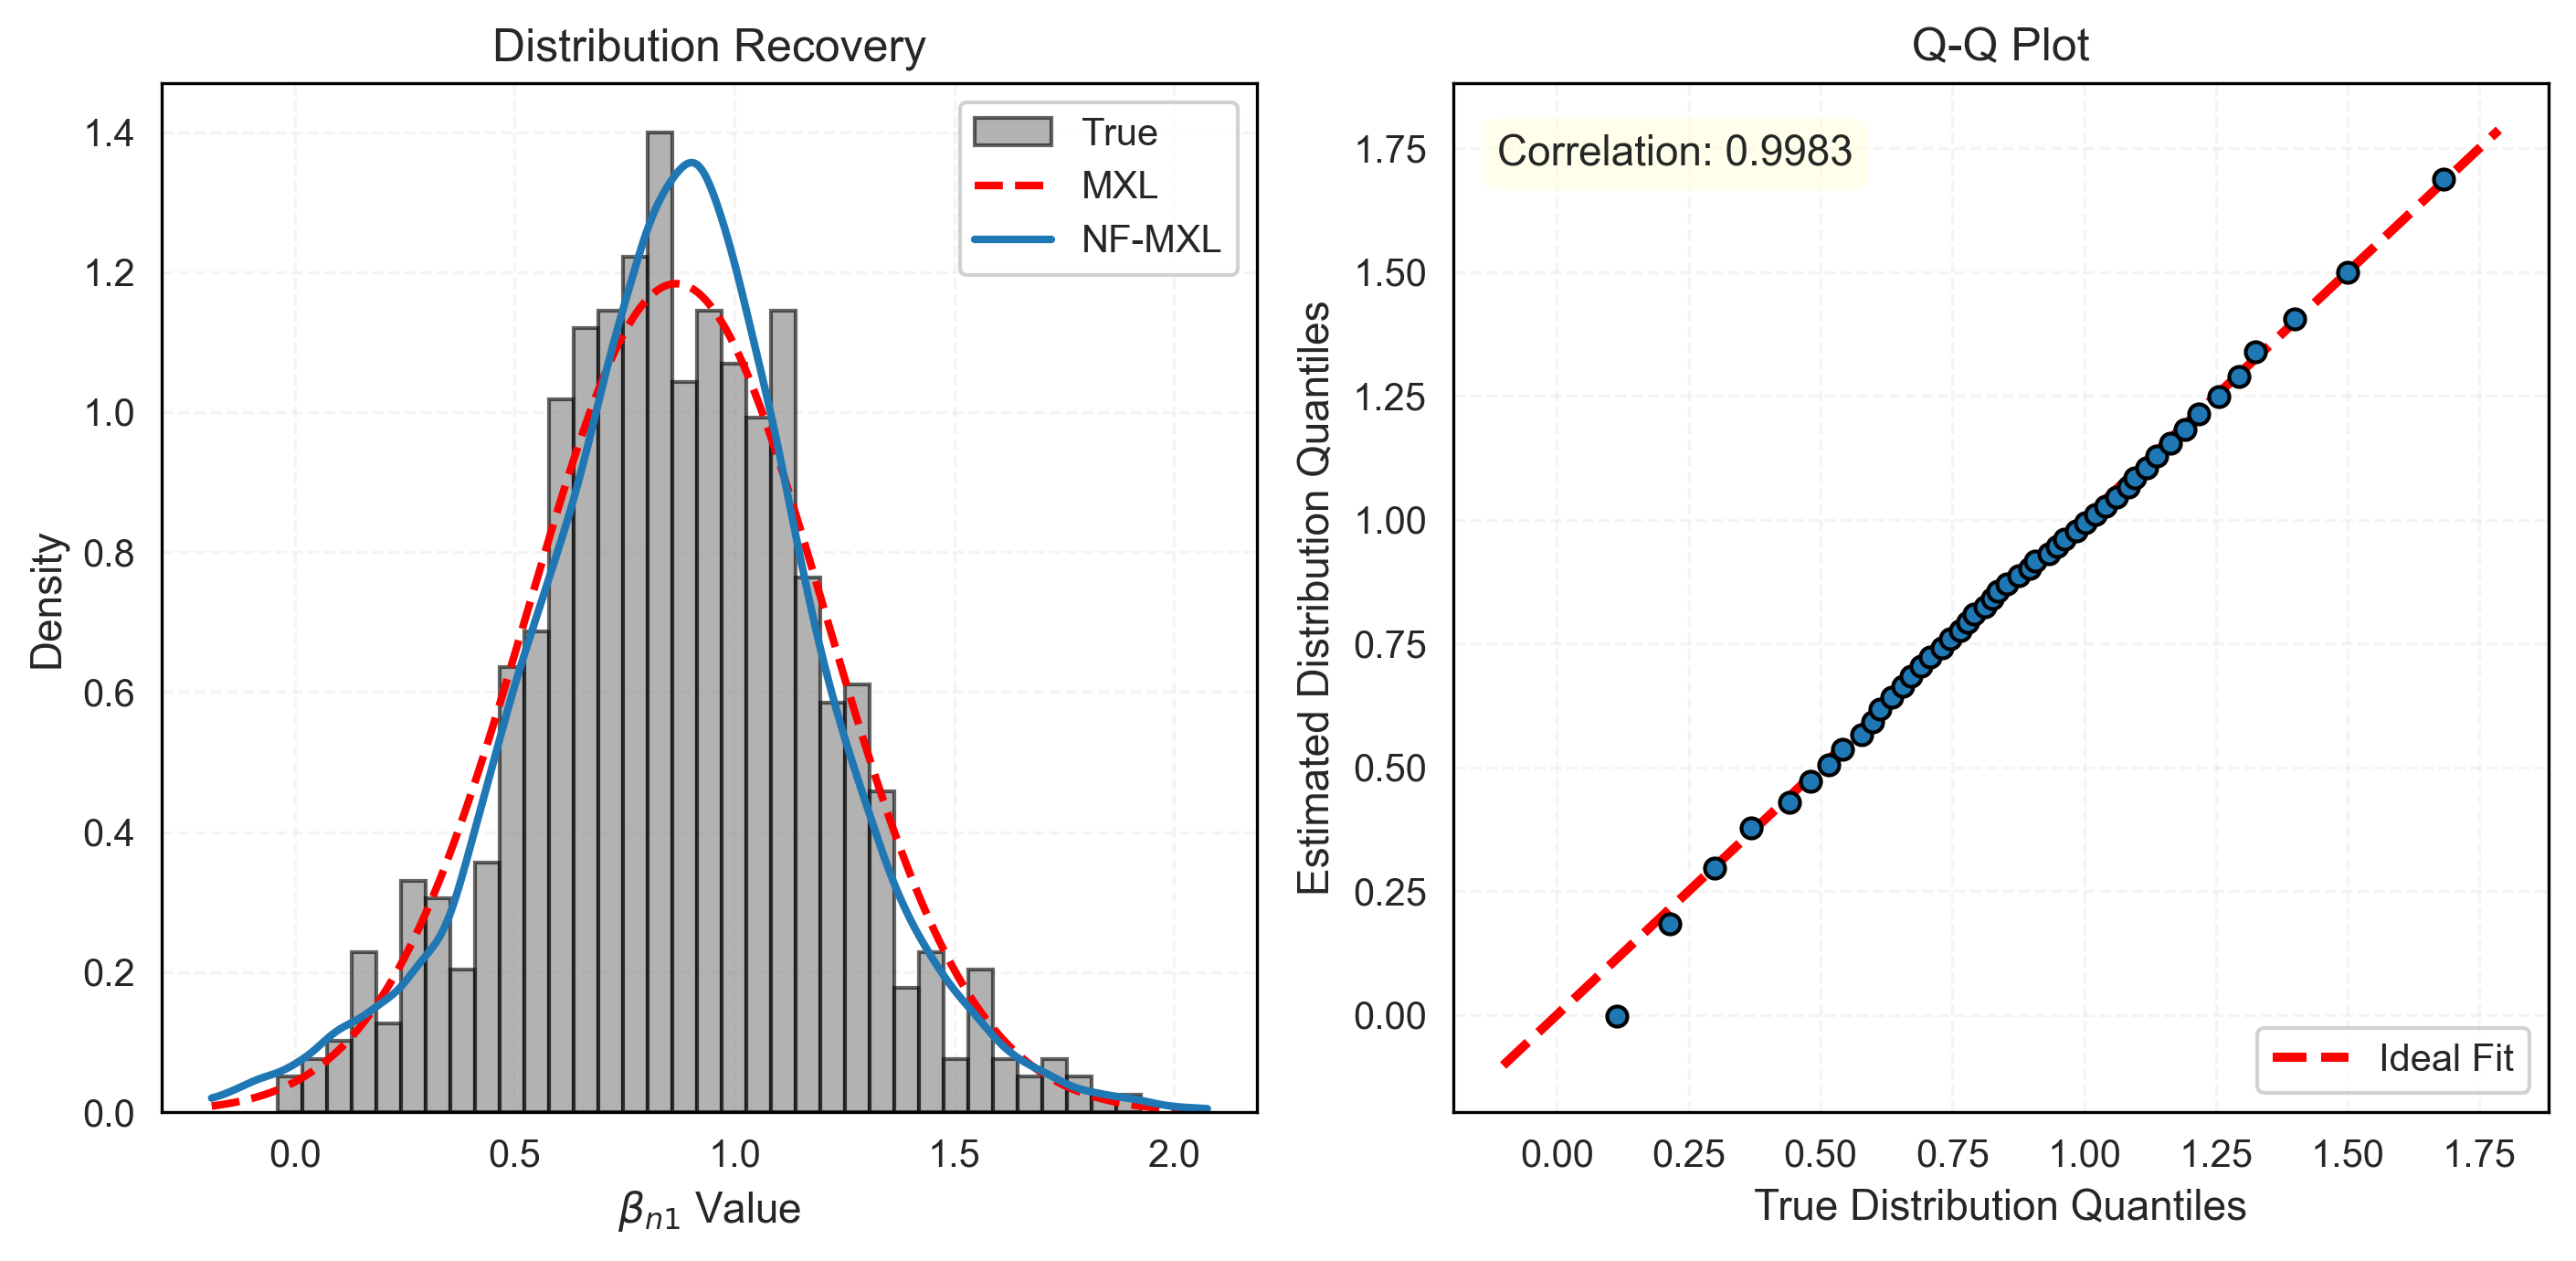

saved: paper_figures\normal_parameter_1_distribution.png


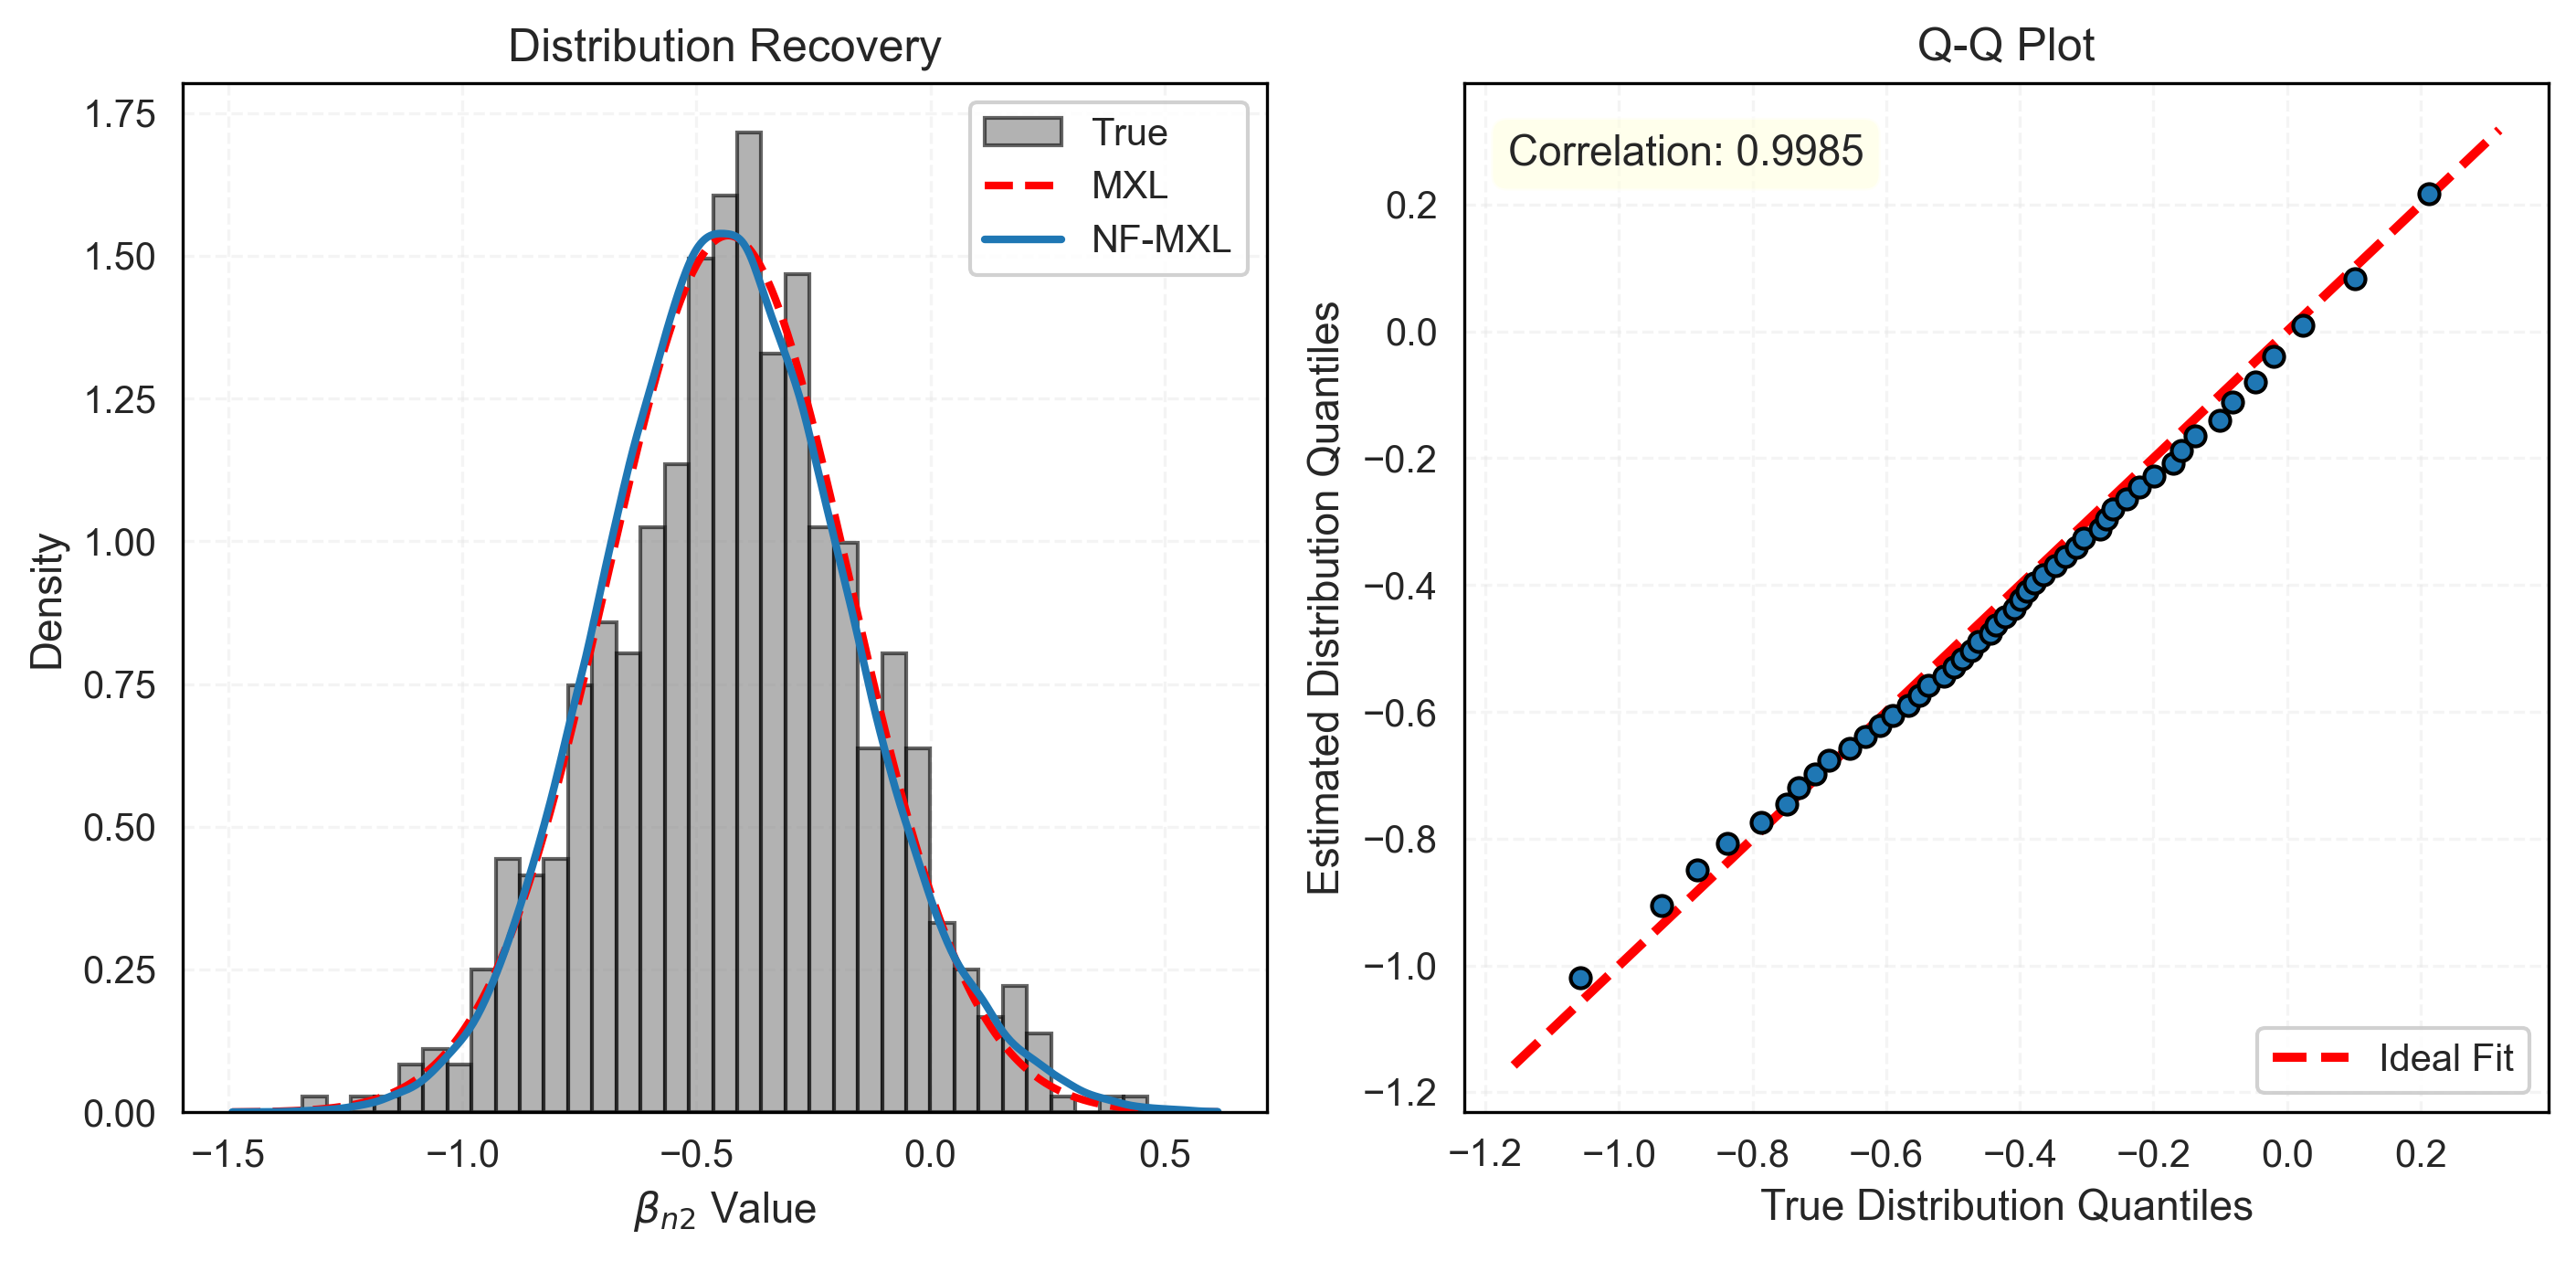

In [15]:
# ---------------- Figure 2 layout (same style as the manuscript) ----------------
plots_dir = Path('./paper_figures')
plots_dir.mkdir(exist_ok=True)

for var_idx in range(len(varnames)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.7))

    true_beta = true_beta_train[:, var_idx]          # training individuals (as in the paper)
    ax1.hist(true_beta, bins=35, density=True, color='gray', alpha=0.6,
             edgecolor='black', label='True')
    x_range = np.linspace(true_beta.min() - 0.15, true_beta.max() + 0.15, 500)
    ax1.plot(x_range, norm.pdf(x_range, ml_means[var_idx], ml_stds[var_idx]),
             'r--', lw=2, label='MXL')
    nf_samples = nf_samples_all[:, var_idx]
    ax1.plot(x_range, gaussian_kde(nf_samples)(x_range), lw=2, color='#1f77b4',
             label='NF-MXL')

    ax1.set_ylabel('Density')
    ax1.set_xlabel(rf"$\beta_{{n{var_idx + 1}}}$ Value")
    ax1.set_title('Distribution Recovery')
    ax1.legend(fontsize=10, frameon=True, framealpha=0.9)
    ax1.grid(True, alpha=0.3, linestyle='--')

    # Q-Q plot (NF-MXL vs true, training individuals)
    qs = np.linspace(1, 99, 49)
    tq = np.percentile(true_beta, qs)
    eq = np.percentile(nf_samples, qs)
    ax2.scatter(tq, eq, color='#1f77b4', edgecolor='k', s=28, zorder=3)
    lim = [min(tq.min(), eq.min()) - 0.1, max(tq.max(), eq.max()) + 0.1]
    ax2.plot(lim, lim, 'r--', lw=2.4, label='Ideal Fit')
    corr_coef = np.corrcoef(tq, eq)[0, 1]
    ax2.text(0.04, 0.95, f'Correlation: {corr_coef:.4f}', transform=ax2.transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.6))
    ax2.set_xlabel('True Distribution Quantiles')
    ax2.set_ylabel('Estimated Distribution Quantiles')
    ax2.set_title('Q-Q Plot')
    ax2.legend(fontsize=10, loc='lower right', frameon=True, framealpha=0.9)
    ax2.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()
    plot_file = plots_dir / f'normal_parameter_{var_idx}_distribution.png'
    plt.savefig(plot_file, dpi=250, bbox_inches='tight')
    print(f'saved: {plot_file}')
    plt.show()

## 7. Reproducibility Notes

* **Seeds and random streams.**
  * DGP: `np.random.seed(2027)`; the raw beta draw, the D-efficient design search,
    the calibration errors (`np.random.seed(2027 + 999)` for the Gumbel errors, then
    back to 2027) and the respondent-level split (`random_state=2027`) consume the
    stream in exactly the same order as the paper's data generator, so the design, the
    scale factor (0.859466), the true log-likelihood (-12643.86), the true $\rho^2$
    (0.2399) and the split are bit-reproducible.
  * Models: `np.random.seed(2024)` + `torch.manual_seed(2024)` (+ CUDA seeds). The
    Mixed Logit train log-likelihood is xlogit's native panel log-likelihood
    (`model.loglikelihood`); the test log-likelihood is evaluated with the same
    per-individual Halton draws and panel construction (the notebook's
    `compute_log_likelihood_mixed_logit` reproduces the native value to the last
    digit on the training set), so both are directly comparable with NF-MXL's
    panel likelihood. NF-MXL training and evaluation draws start from
    the same fixed seed; on GPU the last digits can differ from a CPU run (sampling
    noise), without affecting any conclusion.
* **Dependencies.** `numpy`, `pandas`, `scipy`, `matplotlib`, `seaborn`, `scikit-learn`,
  `torch` (CUDA optional but recommended) and `xlogit`. Versions are printed in §1.
* **Runtime.** Mixed Logit: a single fit takes ~30–60 s on CPU; the reported estimation
  time is that of the selected model only, while the full distribution search over five
  candidates takes a few minutes. NF-MXL: ~1–2 min on one GPU (longer on CPU).
* **Reference.** This notebook corresponds to **Scenario A** of the simulation study —
  **Table 1** and **Figure 2** of the manuscript.